In [1]:
# ==========================================
# 1. Environment Setup & Imports
# ==========================================
%load_ext autoreload
%autoreload 2

import sys
import os
import gc
from pathlib import Path
import torch
import pandas as pd
import numpy as np

# Import Shared Utilities
# Robustly find analysis_utils.py whether running from Root or Subdir
current_dir = Path.cwd()
possible_paths = [
    current_dir,                                         # Case 1: CWD is Notebook Dir
    current_dir / "VisualScripts" / "ResultAnalysis",    # Case 2: CWD is Project Root
    Path(__file__).parent if '__file__' in locals() else current_dir # Case 3: Script execution
]

utils_path = None
for p in possible_paths:
    if (p / "analysis_utils.py").exists():
        utils_path = p
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        print(f"[INFO] Found analysis_utils in: {p}")
        break

if utils_path is None:
    print("[WARN] analysis_utils.py not found in common paths. Please ensure it is accessible.")

try:
    import analysis_utils as utils
    from analysis_utils import PROJECT_ROOT
    print(f"Project Root: {PROJECT_ROOT}")
except ImportError as e:
    raise ImportError(f"Failed to import analysis_utils: {e}. Check if the file exists in {possible_paths}")


[INFO] Found analysis_utils in: d:\PersonFiles\Codes\Project\MACNet v1\VisualScripts\ResultAnalysis
d:\PersonFiles\Codes\Project\MACNet v1\VisualScripts\ResultAnalysis
Project Root: d:\PersonFiles\Codes\Project\MACNet v1


d:\PersonFiles\Codes\Project\MACNet v1\RawDataProcessing\ParseLogFile.py:35: UserWarning: Cannot find folder .config
  warnings.warn(f"Cannot find folder {config_path}")


In [2]:
# ==========================================
# 2. Configuration
# ==========================================
# Experiment Settings
EXP_PREFIX = 'Exp1_'        
DATA_PREFIX = 'Exp1_' 
MODEL_PATH_OVERRIDE = None 

# Paths
RESULTS_DIR = PROJECT_ROOT / 'Results'
CACHE_DIR   = PROJECT_ROOT / '.cache'

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Plotting
FIG_DIR_NAME = 'figures'

Using device: cuda


In [3]:
# ==========================================
# 3. Load Data & Model
# ==========================================
# A. Load Cached Splits
splits = ['train', 'val', 'test']
datasets = {}
print("Loading cached datasets...")
for split in splits:
    pt_path = CACHE_DIR / f"{DATA_PREFIX}{split}.pt"
    if pt_path.exists():
        try:
            ds = utils.CachedPTDataset(pt_path)
            datasets[split] = ds
            print(f"  - [{split.upper()}] Loaded {len(ds)} samples ({ds.kind})")
        except Exception as e:
            print(f"  - [{split.upper()}] Failed to load: {e}")
            datasets[split] = None
    else:
        print(f"  - [{split.upper()}] Not found: {pt_path.name}")
        datasets[split] = None

# B. Find & Load Model
model_path = Path(MODEL_PATH_OVERRIDE) if MODEL_PATH_OVERRIDE else utils.find_latest_model(RESULTS_DIR, EXP_PREFIX)
if not model_path:
    raise RuntimeError(f"No model found for {EXP_PREFIX}")

print(f"Target Model: {model_path}")
model, model_type = utils.load_analysis_model(model_path, DEVICE, datasets)
print(f"Model Type: {model_type}")

# Setup Output Dir
output_dir = model_path.parent
fig_dir = output_dir / FIG_DIR_NAME
fig_dir.mkdir(parents=True, exist_ok=True)
data_save_dir = model_path.parent / 'prediction_data'
data_save_dir.mkdir(parents=True, exist_ok=True)

Loading cached datasets...
  - [TRAIN] Loaded 36186 samples (vit)
  - [VAL] Loaded 4364 samples (vit)
  - [TEST] Loaded 4398 samples (vit)
Target Model: d:\PersonFiles\Codes\Project\MACNet v1\Results\Exp1_ViT20260130_222045\Exp1_ViTbest_model.pth
Model Type: vit


In [4]:
# ==========================================
# 4. Execution: Predictions
# ==========================================
all_results = {}

# A. Cached Test Set
if datasets['test']:
    print(f"Predicting on Cached Test Set...")
    # Request features for H5 saving
    df_test, feats, x_data = utils.predict_dataset(
        datasets['test'], model, DEVICE, model_type, return_feats=True
    )
    df_test['type'] = 'Cached Test'
    all_results['test_cached'] = df_test
    
    # Save H5
    utils.save_to_h5(
        data_save_dir / f"{EXP_PREFIX}test_cached.h5", 
        df_test, feats, x_data, 'test_cached'
    )
    del feats, x_data
    gc.collect()

# B. Raw Datasets (Elliptical Galaxies for Exp1)
# Determine targets
raw_paths = []
# Default list for Elliptical Galaxies
list_eg = [
    'elliptical_galaxy_fiducial', 'elliptical_galaxy_0dot1', 'elliptical_galaxy_pgc'
]

# Use project paths if available, else manual construction
if utils.Exp_eg_folder_paths:
    raw_paths = utils.Exp_eg_folder_paths
else:
    # Manual Fallback
    res = 'coarse'
    for fname in list_eg:
        p = PROJECT_ROOT / 'Data' / fname / res
        if p.exists():
            raw_paths.append((str(p), np.array([0,0])))

print(f"Processing {len(raw_paths)} Raw Datasets...")
dfs_raw = []
for p_conf in raw_paths:
    try:
        ds_raw = utils.HDF5Dataset(p_conf)
        print(f"  > {ds_raw.type} ({len(ds_raw)})")
        
        df, feats, x_data = utils.predict_dataset(
            ds_raw, model, DEVICE, model_type, return_feats=True
        )
        
        # Save individual H5
        utils.save_to_h5(
            data_save_dir / f"{ds_raw.type}.h5", 
            df, feats, x_data, ds_raw.type
        )
        
        dfs_raw.append(df)
        del feats, x_data; gc.collect()
    except Exception as e:
        print(f"  [Error] {p_conf}: {e}")

if dfs_raw:
    all_results['raw_all'] = pd.concat(dfs_raw, ignore_index=True)
    all_results['raw_all'].to_csv(output_dir / "raw_all_predictions.csv", index=False)

Predicting on Cached Test Set...
Processing 3 Raw Datasets...
  > elliptical_galaxy_fiducial (20130)
  > elliptical_galaxy_0dot1 (1225)
  > elliptical_galaxy_pgc (534)


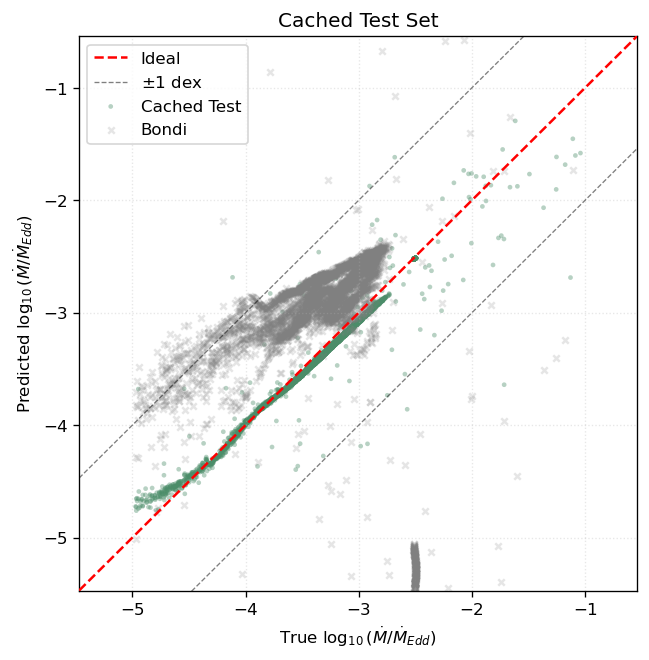

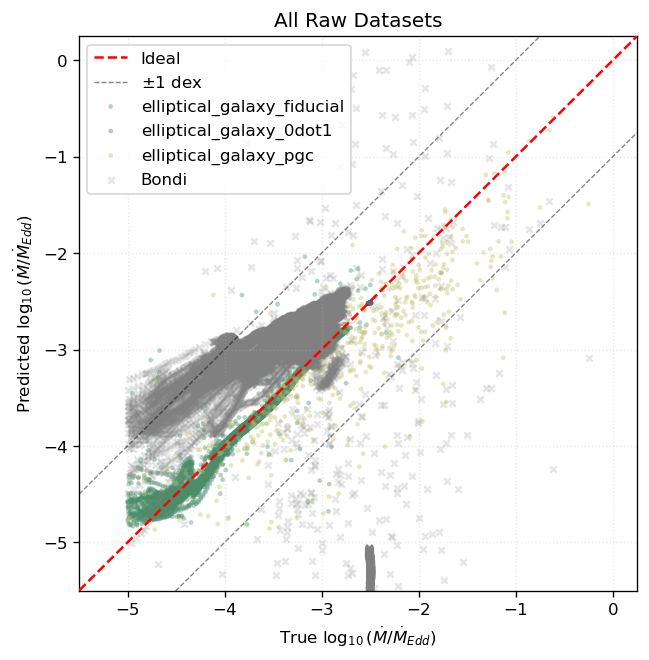

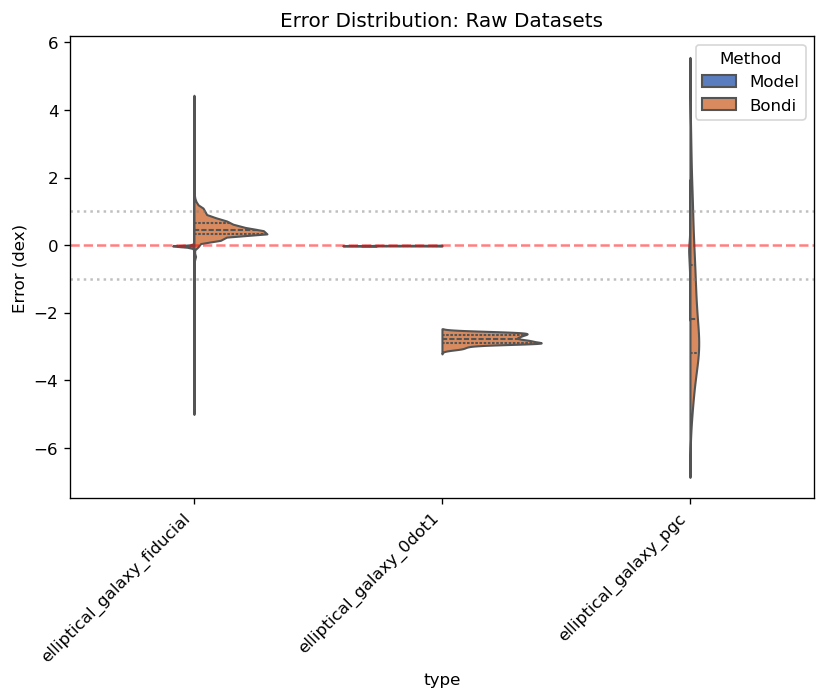

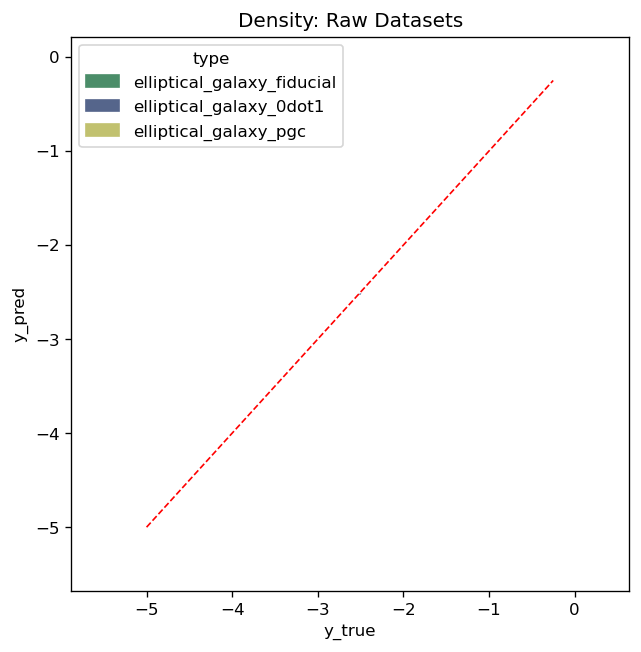

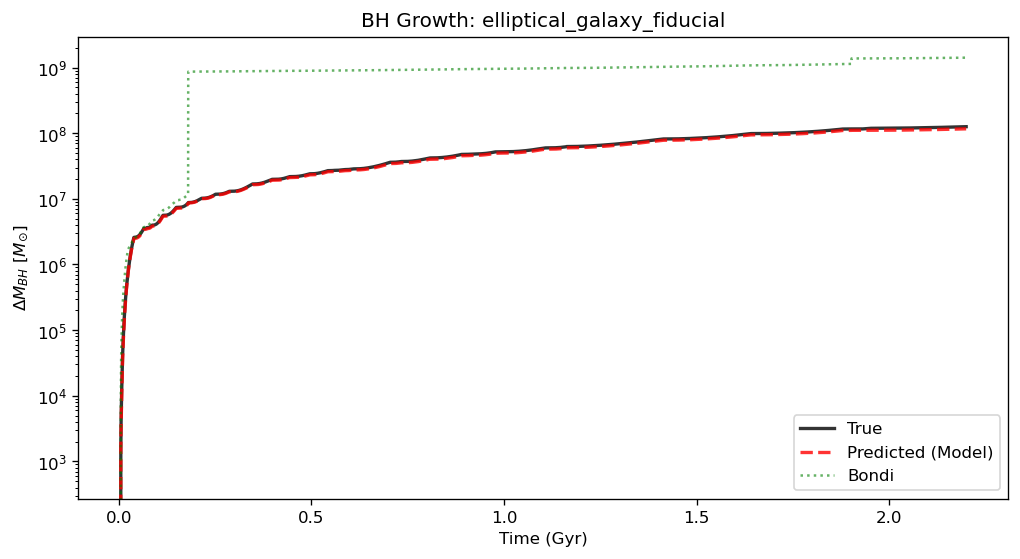

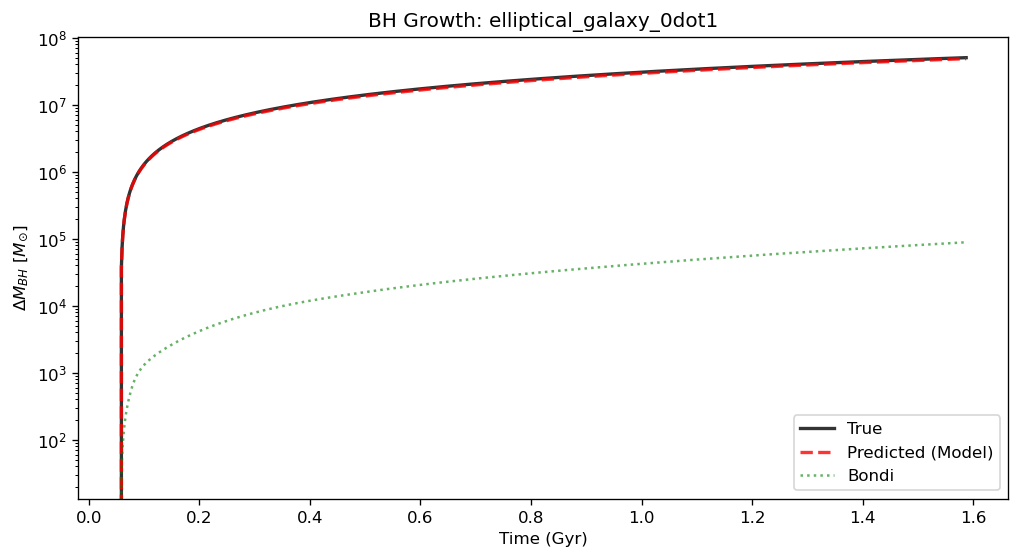

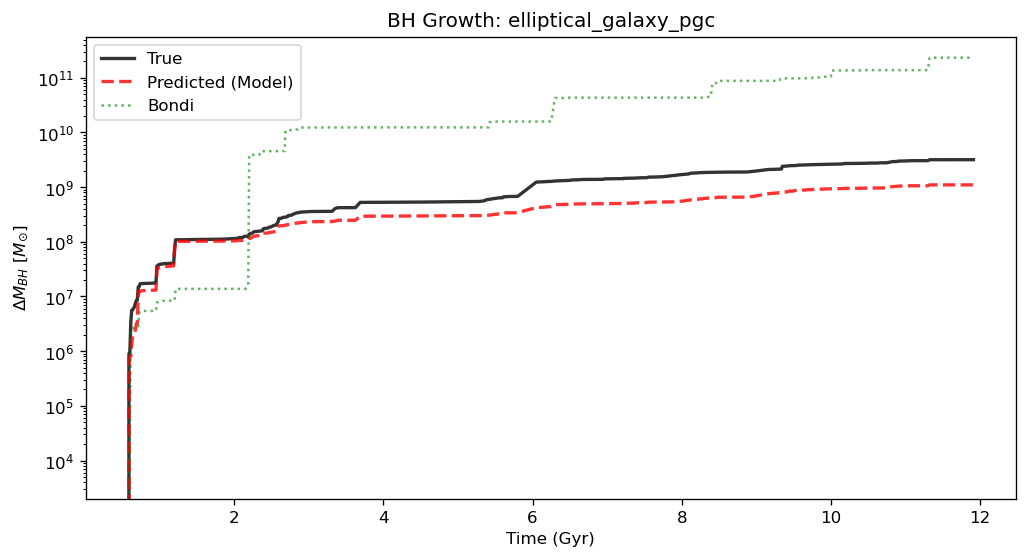

,Dataset,RMSE,MAE,R2,OutlierFrac (>1dex)
0,Cached Test Set,0.116,0.069,0.949,0.205
1,Raw All (Model),0.113,0.050,0.953,0.242
2,Raw All (Bondi),0.957,0.678,-2.349,12.943
3,Type: elliptical_galaxy_fiducial,0.078,0.043,0.973,0.079
4,Type: elliptical_galaxy_0dot1,0.016,0.015,-5.873,0.000
5,Type: elliptical_galaxy_pgc,0.542,0.401,0.586,6.929


In [5]:
# ==========================================
# 5. Visualization & Metrics
# ==========================================
metrics_list = []

# Helper 
def process_result(key, name):
    if key in all_results:
        df = all_results[key]
        metrics_list.append(utils.get_metrics_summary(df['y_true'], df['y_pred'], name))
        utils.plot_scatter(df, name, fig_dir)
        return df
    return None

# 1. Cached Test
process_result('test_cached', "Cached Test Set")

# 2. Raw Data
if 'raw_all' in all_results:
    df_raw = all_results['raw_all']
    metrics_list.append(utils.get_metrics_summary(df_raw['y_true'], df_raw['y_pred'], "Raw All (Model)"))
    
    if 'y_bondi' in df_raw.columns:
         valid_b = df_raw.dropna(subset=['y_bondi'])
         metrics_list.append(utils.get_metrics_summary(valid_b['y_true'], valid_b['y_bondi'], "Raw All (Bondi)"))

    utils.plot_scatter(df_raw, "All Raw Datasets", fig_dir)
    utils.plot_error_dist(df_raw, "Raw Datasets", fig_dir)
    utils.plot_kde_contour(df_raw, "Raw Datasets", fig_dir)
    
    # Per Galaxy Type plots
    for t in df_raw['type'].unique():
        sub = df_raw[df_raw['type'] == t]
        metrics_list.append(utils.get_metrics_summary(sub['y_true'], sub['y_pred'], f"Type: {t}"))
        utils.plot_mass_evolution(sub, t, fig_dir)

# 3. Summary Table
metrics_df = pd.DataFrame(metrics_list)
pd.options.display.float_format = '{:,.3f}'.format
display(metrics_df)
metrics_df.to_csv(output_dir / "summary_metrics.csv", index=False)

In [6]:
# ==========================================
# 6. Save Markdown Report
# ==========================================
md_path = output_dir / "summary_metrics.md"
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(f"# Analysis Results: {EXP_PREFIX}\n\n")
    f.write(f"- **Model**: `{model_path.name}`\n")
    f.write(f"- **Type**: `{model_type}`\n\n")
    
    f.write("## Metrics\n")
    f.write(metrics_df.to_markdown(floatfmt=".3f"))
    
    f.write("\n\n## Visualizations\n")
    for img in sorted(fig_dir.glob(f"*.png")):
        f.write(f"### {img.stem}\n![{img.stem}]({FIG_DIR_NAME}/{img.name})\n\n")
        
print(f"Saved report to {md_path}")

Saved report to d:\PersonFiles\Codes\Project\MACNet v1\Results\Exp1_ViT20260130_222045\summary_metrics.md
